# Calibração dos limiares de hesitação — BAH

Calibra os limiares do `HesitationExtractor` (bloco `data.tabular.hesitation`) contra o **rótulo por janela** (`label` 0/1, derivado da sobreposição com `time_detailed_ah`), com **gráficos de AUC-vs-limiar** e **distribuições por classe**.

**Estratégia** (ver conversa): os limiares são calibrados por *varredura univariada* contra o `label` de janela (proxy barato e granular). Confirme os finalistas no **macro-F1 por vídeo** (a métrica oficial) via multirun do Hydra — ver a última célula.

**Pré-requisitos**
- Kernel = o `.venv` do projeto (tem `parselmouth`, `librosa`, `seaborn`).
- Índice de janelas gerado: `uv run python main.py mode=preprocess`.
- (Opcional, só p/ o Passo 1) cache de features: `uv run python main.py mode=featurize data.tabular.use_hesitation=true`.

> ⚠️ Calibre **só no split de treino** (ou val). Nunca escolha limiares olhando o `test`.

In [10]:
import sys, warnings
from pathlib import Path
import numpy as np, polars as pl
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

def find_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for d in [p, *p.parents]:
        if (d / "configs").is_dir() and (d / "pyproject.toml").is_file():
            return d
    raise RuntimeError("Raiz do projeto nao encontrada (procuro configs/ + pyproject.toml).")

ROOT = find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Projeto:", ROOT)

from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra

# Edite os overrides como faria na CLI do Hydra:
OVERRIDES = ["data.tabular.use_hesitation=true"]

GlobalHydra.instance().clear()
with initialize_config_dir(version_base=None, config_dir=str(ROOT / "configs")):
    cfg = compose(config_name="config", overrides=OVERRIDES)
print("audio backend:", cfg.audio_embedder.backend, "| use_hesitation:", cfg.data.tabular.use_hesitation)

Projeto: /Users/lfbf/Documents/Projetos_Academicos/Liga_IA_OneDrive/abaw-11-ah-challenge
audio backend: librosa | use_hesitation: True


## Parâmetros de calibração e grades de varredura
Edite `SPLIT`, `MAX_WINDOWS` (0 = todas; subamostre p/ ir mais rápido) e as grades.

In [11]:
from sklearn.metrics import roc_auc_score

SPLIT = "train"     # split p/ calibrar (NUNCA test)
MAX_WINDOWS = 0     # 0 = todas; int p/ subamostrar (mais rapido)
SEED = 42

# Grades (Tipo A = corte sobre serie ja calculada; top_db recomputa o VAD, mas e barato)
GRIDS = {
    "long_pause_s":          np.round(np.arange(0.10, 0.81, 0.05), 3),
    "min_pause_s":           np.round(np.arange(0.02, 0.31, 0.02), 3),
    "plateau_tol":           np.round(np.arange(0.02, 0.241, 0.02), 3),
    "hf_cutoff_hz":          np.array([500, 750, 1000, 1250, 1500, 2000, 2500, 3000, 4000], float),
    "silence_rms_threshold": np.array([0.005, 0.01, 0.02, 0.04, 0.06, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]),
    "top_db":                np.array([10, 12, 15, 18, 20, 22, 25, 30, 35, 40], float),
}
UNITS = {"long_pause_s": "s", "min_pause_s": "s", "plateau_tol": "frac",
         "hf_cutoff_hz": "Hz", "silence_rms_threshold": "frac", "top_db": "dB"}

def auc_dir(y, f):
    # AUC da feature vs label + discriminancia |AUC-0.5| (robusto a feature constante / 1 classe)
    f = np.nan_to_num(np.asarray(f, dtype=float))
    if f.size == 0 or np.unique(f).size < 2:
        return 0.5, 0.0
    try:
        a = float(roc_auc_score(y, f))
    except Exception:
        return 0.5, 0.0
    return a, abs(a - 0.5)

## Carregar janelas + waveforms
Usa o índice de janelas da FASE 2 e corta cada waveform em `[t0, t1]` (mesma convenção do `FeatureBuilder`). O `HesitationExtractor` é instanciado só para herdar os parâmetros-base (frame/hop/F0) e os valores atuais do YAML.

In [12]:
from src.data.windowing import load_window_index
from src.data.audio_io import load_segment
from src.features.hesitation import HesitationExtractor

SR = int(cfg.data.audio.sample_rate)
_MIN_WAVE_S = 0.5  # espelha o FeatureBuilder (evita erro do librosa em janelas curtas)
audio_dir = ROOT / cfg.data.paths.interim_dir / "Audio"
win_index = ROOT / cfg.data.paths.interim_dir / "windows_index.parquet"
assert win_index.exists(), f"Indice ausente: {win_index}. Rode 'python main.py mode=preprocess'."

windows = [w for w in load_window_index(win_index) if w.split == SPLIT and w.label is not None]
print(f"{len(windows)} janelas no split '{SPLIT}' com rotulo.")

rng = np.random.default_rng(SEED)
if MAX_WINDOWS and len(windows) > MAX_WINDOWS:
    sel = sorted(rng.choice(len(windows), size=MAX_WINDOWS, replace=False).tolist())
    windows = [windows[i] for i in sel]
    print(f"Subamostrado para {len(windows)} janelas (MAX_WINDOWS={MAX_WINDOWS}).")

def load_wave(w):
    stem = Path(w.video_id).stem
    flac = audio_dir / w.participant_id / f"{stem}.flac"
    seg = load_segment(flac, w.t0, w.t1, sr=SR) if flac.exists() else np.zeros(0, np.float32)
    min_len = int(SR * _MIN_WAVE_S)
    if seg.size < min_len:
        pad = np.zeros(min_len, np.float32); pad[: seg.size] = seg; seg = pad
    return seg

ext = HesitationExtractor.from_config(cfg.data.tabular.hesitation, sample_rate=SR)
CURRENT = {k: float(getattr(ext, k)) for k in GRIDS}
print("Valores atuais (YAML):", CURRENT)

8540 janelas no split 'train' com rotulo.
Valores atuais (YAML): {'long_pause_s': 0.5, 'min_pause_s': 0.15, 'plateau_tol': 0.05, 'hf_cutoff_hz': 2000.0, 'silence_rms_threshold': 0.1, 'top_db': 30.0}


## Passo 2 — uma passada: features por limiar
Para cada janela, computa a quantidade subjacente **uma vez** (RMS, energia por frequência, série de F0, pausas) e avalia a feature em **toda a grade** do limiar. Barato: nada re-roda o parselmouth por valor de limiar.

In [13]:
import librosa, parselmouth
from tqdm.auto import tqdm

y = np.array([int(w.label) for w in windows])
assert set(np.unique(y).tolist()) >= {0, 1}, "Precisa das duas classes (0 e 1) no split."
print("Positivos (hesitacao):", int(y.sum()), "/", len(y), f"({y.mean():.1%})")

freqs = librosa.fft_frequencies(sr=SR, n_fft=ext.frame_length)

def internal_gaps(wav, top_db):
    iv = librosa.effects.split(wav, top_db=top_db, frame_length=ext.frame_length, hop_length=ext.hop_length)
    gaps = []
    for k in range(len(iv) - 1):
        g = (iv[k + 1, 0] - iv[k, 1]) / SR
        if g > 0:
            gaps.append(float(g))
    return gaps

F = {k: np.zeros((len(windows), len(GRIDS[k])), np.float32) for k in GRIDS}

for i, w in enumerate(tqdm(windows, desc="janelas")):
    wav = load_wave(w)
    dur = max(wav.size / SR, 1e-6)

    rms = librosa.feature.rms(y=wav, frame_length=ext.frame_length, hop_length=ext.hop_length)[0]
    rmax = float(rms.max()) if rms.size else 0.0
    if rmax > 0:
        F["silence_rms_threshold"][i] = [np.mean(rms < s * rmax) for s in GRIDS["silence_rms_threshold"]]

    S = np.abs(librosa.stft(wav, n_fft=ext.frame_length, hop_length=ext.hop_length))
    ebf = (S ** 2).sum(axis=1); tot = float(ebf.sum()) + 1e-8
    F["hf_cutoff_hz"][i] = [ebf[freqs >= c].sum() / tot for c in GRIDS["hf_cutoff_hz"]]

    try:
        snd = parselmouth.Sound(wav.astype(float), sampling_frequency=SR)
        pitch = snd.to_pitch(time_step=ext.hop_length / SR, pitch_floor=ext.f0_min, pitch_ceiling=ext.f0_max)
        f0 = np.asarray(pitch.selected_array["frequency"]); f0v = f0[f0 > 0]
    except Exception:
        f0v = np.array([])
    if f0v.size:
        med = float(np.median(f0v))
        F["plateau_tol"][i] = [np.mean(np.abs(f0v / (med + 1e-8) - 1.0) <= t) for t in GRIDS["plateau_tol"]]

    gaps = internal_gaps(wav, ext.top_db)
    F["long_pause_s"][i] = [sum(g for g in gaps if g > L) / dur for L in GRIDS["long_pause_s"]]
    F["min_pause_s"][i]  = [len([g for g in gaps if g >= m]) / dur for m in GRIDS["min_pause_s"]]

    for j, td in enumerate(GRIDS["top_db"]):
        g_td = internal_gaps(wav, float(td))
        F["top_db"][i, j] = sum(g for g in g_td if g > ext.long_pause_s) / dur

print("Matrizes prontas:", {k: v.shape for k, v in F.items()})

Positivos (hesitacao): 1185 / 8540 (13.9%)


janelas: 100%|██████████| 8540/8540 [00:44<00:00, 192.15it/s]

Matrizes prontas: {'long_pause_s': (8540, 15), 'min_pause_s': (8540, 15), 'plateau_tol': (8540, 12), 'hf_cutoff_hz': (8540, 9), 'silence_rms_threshold': (8540, 11), 'top_db': (8540, 10)}


## Curvas AUC × limiar
Cada ponto = poder discriminativo (AUC contra o `label` de janela) da feature com aquele valor de limiar. Vermelho = melhor; verde pontilhado = valor atual no YAML. Longe de 0.5 é melhor (para os dois lados — a direção o modelo aprende).

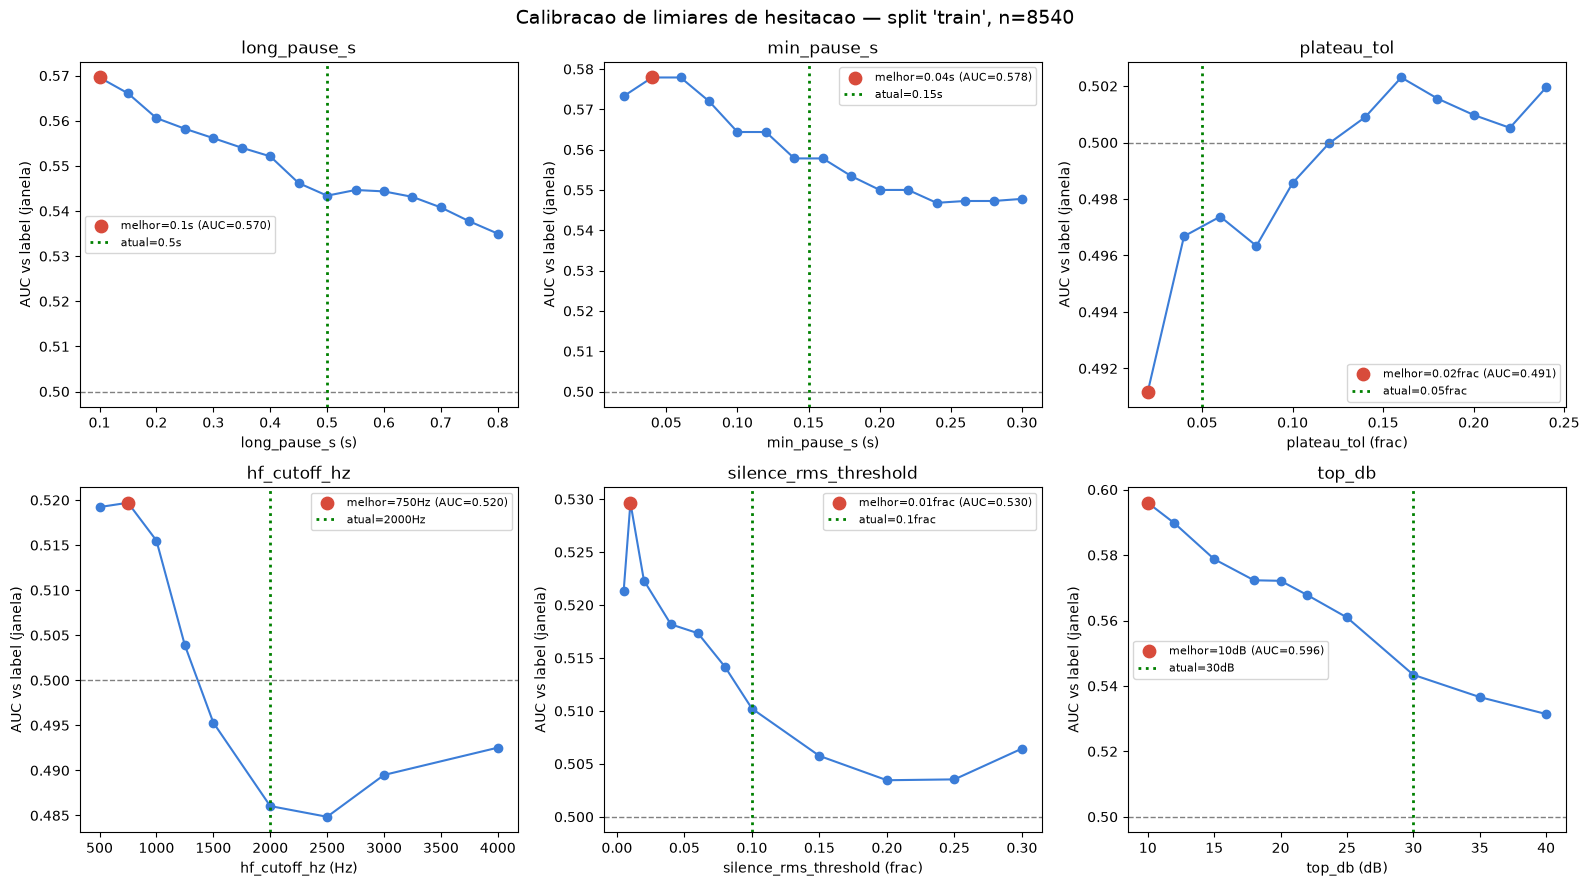

In [14]:
best = {}
fig, axes = plt.subplots(2, 3, figsize=(16, 9)); axes = axes.ravel()
for ax, k in zip(axes, GRIDS):
    grid = GRIDS[k]
    aucs = np.array([auc_dir(y, F[k][:, j])[0] for j in range(len(grid))])
    b = int(np.argmax(np.abs(aucs - 0.5)))
    best[k] = (float(grid[b]), float(aucs[b]))
    ax.plot(grid, aucs, "-o", color="#3b7dd8")
    ax.axhline(0.5, ls="--", c="gray", lw=1)
    ax.scatter([grid[b]], [aucs[b]], color="#d84b3b", zorder=5, s=80,
               label=f"melhor={grid[b]:g}{UNITS[k]} (AUC={aucs[b]:.3f})")
    ax.axvline(CURRENT[k], ls=":", c="green", lw=2, label=f"atual={CURRENT[k]:g}{UNITS[k]}")
    ax.set(title=k, xlabel=f"{k} ({UNITS[k]})", ylabel="AUC vs label (janela)")
    ax.legend(fontsize=8, loc="best")
fig.suptitle(f"Calibracao de limiares de hesitacao — split '{SPLIT}', n={len(y)}", fontsize=14)
fig.tight_layout(); plt.show()

## Distribuições por classe (no melhor limiar)
Densidade da feature para janelas **hesitantes** vs **não-hesitantes**, no melhor valor de cada limiar. Quanto menos as curvas se sobrepõem, mais separável.

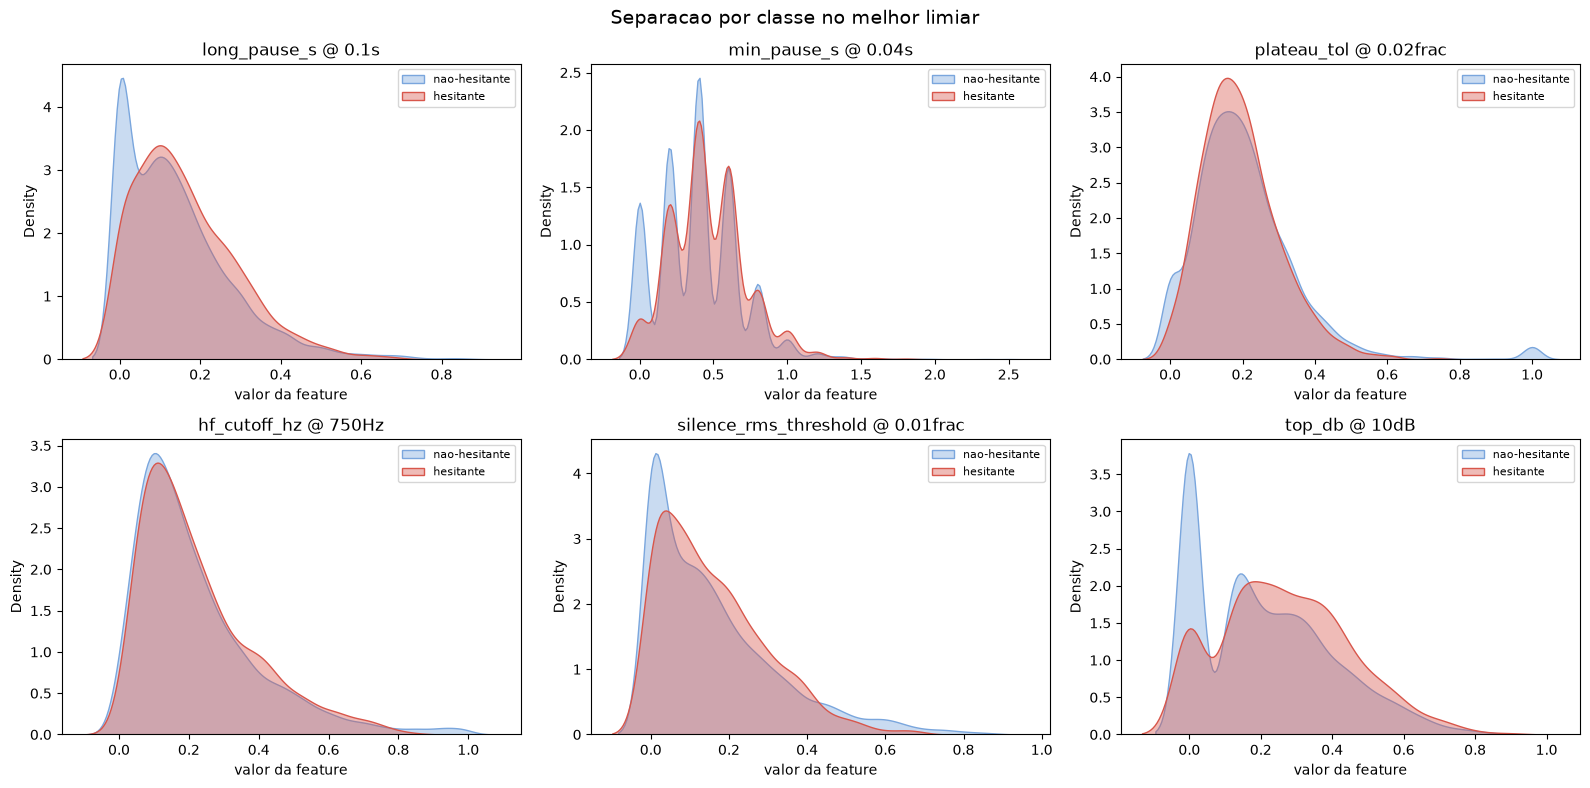

In [15]:
import seaborn as sns
fig, axes = plt.subplots(2, 3, figsize=(16, 8)); axes = axes.ravel()
for ax, k in zip(axes, GRIDS):
    grid = GRIDS[k]
    b = int(np.argmax([abs(auc_dir(y, F[k][:, j])[0] - 0.5) for j in range(len(grid))]))
    feat = F[k][:, b]
    for cls, color, lbl in [(0, "#7aa6dd", "nao-hesitante"), (1, "#d8564b", "hesitante")]:
        sns.kdeplot(feat[y == cls], ax=ax, fill=True, alpha=0.4, color=color, label=lbl, warn_singular=False)
    ax.set(title=f"{k} @ {grid[b]:g}{UNITS[k]}", xlabel="valor da feature")
    ax.legend(fontsize=8)
fig.suptitle("Separacao por classe no melhor limiar", fontsize=14); fig.tight_layout(); plt.show()

## Passo 1 (opcional) — features de hesitação já no cache
Se você já rodou `featurize` com `use_hesitation=true`, isto lê o Parquet e mede a discriminância (|AUC-0.5|) de **cada** feature `hes_*` como está hoje — útil para ver quais features carregam sinal (independe de limiar).

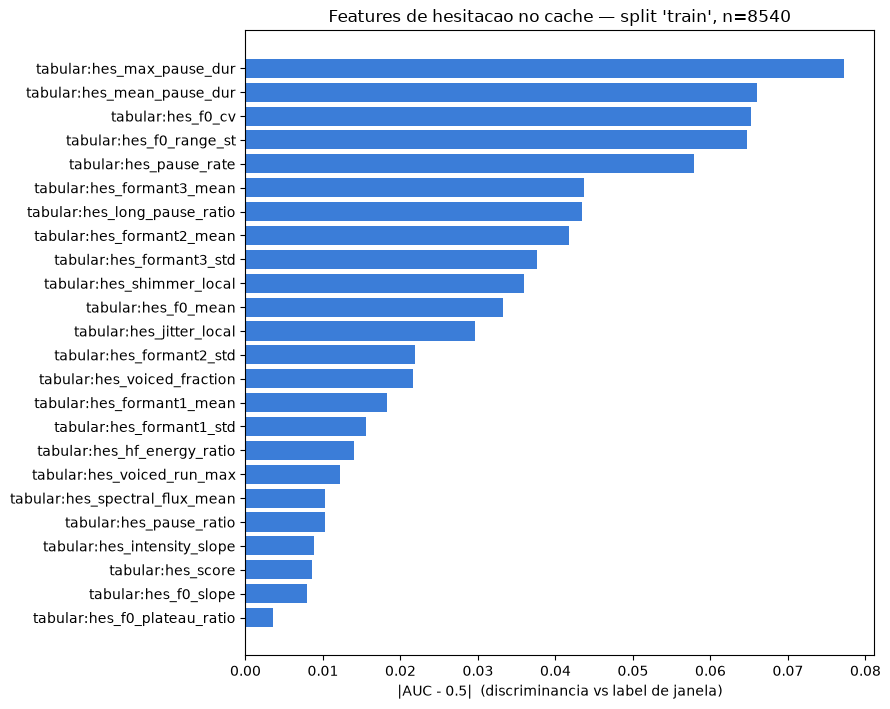

In [16]:
import json
pq = ROOT / cfg.data.paths.parquet_path
side = pq.with_suffix(".json")
if pq.exists() and side.exists():
    meta = json.loads(side.read_text())
    df = pl.read_parquet(pq).filter((pl.col("split") == SPLIT) & (pl.col("label") >= 0))
    yc = df["label"].to_numpy()
    rows = []
    for group, col in [("tabular", "tabular"), ("audio", "audio_emb")]:
        names = meta["feature_names"].get(group, [])
        hes = [(n, j) for j, n in enumerate(names) if n.startswith("hes_")]
        if not hes:
            continue
        M = np.vstack(df[col].to_numpy())
        for n, j in hes:
            a, d = auc_dir(yc, M[:, j]); rows.append((f"{group}:{n}", a, d))
    if rows:
        rows.sort(key=lambda r: r[2])
        nm = [r[0] for r in rows]; dd = [r[2] for r in rows]
        plt.figure(figsize=(9, max(4, len(nm) * 0.30)))
        plt.barh(nm, dd, color="#3b7dd8")
        plt.xlabel("|AUC - 0.5|  (discriminancia vs label de janela)")
        plt.title(f"Features de hesitacao no cache — split '{SPLIT}', n={len(yc)}")
        plt.tight_layout(); plt.show()
    else:
        print("Cache sem features 'hes_'. Rode: python main.py mode=featurize data.tabular.use_hesitation=true")
else:
    print(f"Cache nao encontrado ({pq}). Rode 'python main.py mode=featurize' ou pule o Passo 1.")

## Resumo + YAML pronto para colar
Melhores limiares (máx. |AUC-0.5|) e um bloco `hesitation:` pronto. **Estes são candidatos** — varreduras univariadas contra o rótulo de janela.

In [17]:
print(f"Melhores limiares no split '{SPLIT}':\n")
for k in GRIDS:
    v, a = best[k]; cur = CURRENT[k]
    flag = "   <== muda" if abs(v - cur) > 1e-9 else ""
    print(f"  {k:24s} {v:>8g} {UNITS[k]:4s}  (AUC={a:.3f}, atual={cur:g}){flag}")

order = ["frame_length", "hop_length", "silence_rms_threshold", "top_db", "min_pause_s",
         "long_pause_s", "f0_min", "f0_max", "plateau_tol", "n_formants",
         "max_formant_hz", "hf_cutoff_hz", "use_praat"]
print("\n# ---- cole em configs/data/default.yaml sob 'tabular:' ----")
print("  hesitation:")
for k in order:
    val = best[k][0] if k in best else getattr(ext, k)
    if k in ("frame_length", "hop_length", "n_formants"):
        val = int(val)
    elif isinstance(val, bool):
        val = str(val).lower()  # estilo YAML (true/false)
    print(f"    {k}: {val}")

Melhores limiares no split 'train':

  long_pause_s                  0.1 s     (AUC=0.570, atual=0.5)   <== muda
  min_pause_s                  0.04 s     (AUC=0.578, atual=0.15)   <== muda
  plateau_tol                  0.02 frac  (AUC=0.491, atual=0.05)   <== muda
  hf_cutoff_hz                  750 Hz    (AUC=0.520, atual=2000)   <== muda
  silence_rms_threshold        0.01 frac  (AUC=0.530, atual=0.1)   <== muda
  top_db                         10 dB    (AUC=0.596, atual=30)   <== muda

# ---- cole em configs/data/default.yaml sob 'tabular:' ----
  hesitation:
    frame_length: 2048
    hop_length: 512
    silence_rms_threshold: 0.01
    top_db: 10.0
    min_pause_s: 0.04
    long_pause_s: 0.1
    f0_min: 65.0
    f0_max: 500.0
    plateau_tol: 0.02
    n_formants: 3
    max_formant_hz: 5500.0
    hf_cutoff_hz: 750.0
    use_praat: true


## Confirmação no metric real (macro-F1 por vídeo)
As curvas acima usam o **rótulo de janela** (proxy). Para fixar os valores, confirme os 2–3 finalistas otimizando o **macro-F1 na val** de ponta a ponta (o RandomForest é barato/CPU):

```bash
uv run python main.py -m mode=featurize,train \
  data.tabular.hesitation.long_pause_s=0.4,0.5,0.6 \
  data.tabular.hesitation.top_db=25,30,35 \
  data.force=true
```

Compare o macro-F1 de validação entre as combinações e fixe os vencedores no YAML. Lembre: cada valor muda o cache de features (o `cfg_hash` inclui a config de hesitação), por isso o `data.force=true`.